## Plotting ESHI simulation inputs and results

Rachel Middleton

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from netCDF4 import Dataset

In [2]:
def get_nc_files(folder):
    inputfileA = folder +'/SteadyStateA/ESHI.SteadyStateA.out.nc'
    inputfileB = folder +'/SteadyStateB/ESHI.SteadyStateB.out.nc'
    inputfileC = folder +'/SteadyStateC/ESHI.SteadyStateC.out.nc'
    inputfileD = folder +'/SteadyStateD/ESHI.SteadyStateD.out.nc'
    inputfileE = folder +'/SteadyStateE/ESHI.SteadyStateE.out.nc'
    inputfileF = folder +'/SteadyStateF/ESHI.SteadyStateF.out.nc'


    ncfileA = Dataset(inputfileA, 'r')
    ncfileB = Dataset(inputfileB, 'r')
    ncfileC = Dataset(inputfileC, 'r')
    ncfileD = Dataset(inputfileD, 'r')
    ncfileE = Dataset(inputfileE, 'r')
    ncfileF = Dataset(inputfileF, 'r')

    return ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF

In [3]:
# make a comparison plot

def make_subplot(ax,ncfile,title):
    x = ncfile.variables['x1'][:]
    y = ncfile.variables['y1'][:]
    X, Y = np.meshgrid(x, y)
    Z = ncfile.variables['effecpress'][1][:]
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                    cmap='viridis', edgecolor='none')
    ax.set_title(title)
    # x and y labels
    ax.set_xlabel('x')
    ax.set_ylabel('y')


def make_3D_plots(ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, title):
    fig = plt.figure()

    ax1 = fig.add_subplot(231, projection='3d')
    make_subplot(ax1,ncfileA,'A1')

    ax2 = fig.add_subplot(232, projection='3d')
    make_subplot(ax2,ncfileB,'A2')

    ax3 = fig.add_subplot(233, projection='3d')
    make_subplot(ax3,ncfileC,'A3')

    ax4 = fig.add_subplot(234, projection='3d')
    make_subplot(ax4,ncfileD,'A4')

    ax5 = fig.add_subplot(235, projection='3d')
    make_subplot(ax5,ncfileE,'A5')

    ax6 = fig.add_subplot(236, projection='3d')
    make_subplot(ax6,ncfileF,'A6')

    plt.suptitle(title)

    plt.show()

In [4]:
folders = ['SHMIP_g_1.5_t_0.02',
           'SHMIP_g_1.5_t_0.01',
           'SHMIP_g_1_t_0.01',
           'SHMIP_g_1_t_0.005',
           'SHMIP_g_1_t_0.02']

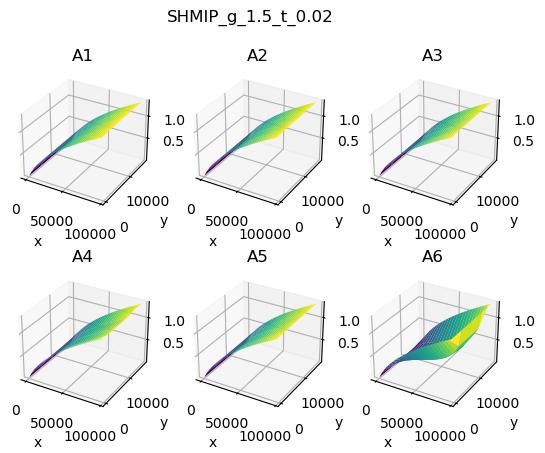

In [5]:
ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF = get_nc_files(folders[0])
make_3D_plots(ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, folders[0])

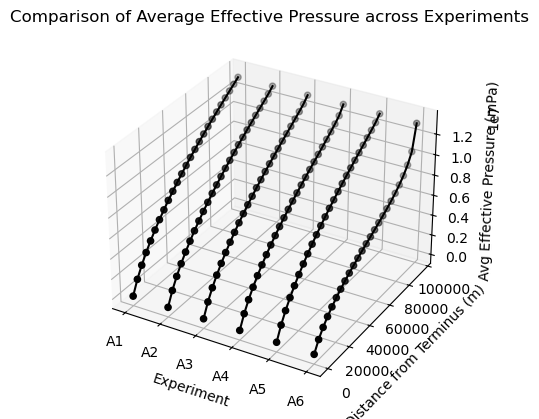

In [6]:
# Function to calculate the average effective pressure for a given ncfile
def calculate_average_effective_pressure(ncfile):
    x = ncfile.variables['x1'][:]  # Distance from the terminus
    
    Z = ncfile.variables['effecpress'][1][:]  # Effective pressure
    # print(Z)
    
    average_Z = np.mean(Z, axis=0)  # Averaging across the y-axis
    
    # variance_Z = np.var(Z, axis=0)  # Variance across the x-axis
    
    average_Z = np.ones((1,len(x))) * average_Z  # Repeat the average_Z to match the shape of y
    # variance_Z = np.ones((1,len(x))) * variance_Z  # Repeat the variance_Z to match the shape of y
    return x, average_Z

# Create figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Experiment labels
experiment_labels = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']
x_experiment = np.arange(len(experiment_labels))  # Numerical representation of experiments


# For each experiment, calculate and plot the average effective pressure
for i, (ncfile, label) in enumerate(zip([ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF], experiment_labels)):
    x, average_Z = calculate_average_effective_pressure(ncfile)  # Get y and Z for each experiment
    X, Y = np.meshgrid(x_experiment[i], x)  # Create meshgrid for plotting
    # ax.plot_surface(X, Y, average_Z, rstride=1, cstride=1, cmap='coolwarm', edgecolor='none', label=label)
    ax.scatter(X, Y, average_Z, c='black', label=label)
    ax.plot(X, Y, average_Z.T, c='black')


# Set labels
ax.set_xlabel('Experiment')
ax.set_ylabel('Distance from Terminus (m)')
ax.set_zlabel('Avg Effective Pressure (mPa)')

# Set experiment labels on x-axis
ax.set_xticks(x_experiment)
ax.set_xticklabels(experiment_labels)

plt.title('Comparison of Average Effective Pressure across Experiments')
plt.show()


In [7]:
def make_effecpress_subplot(ax,ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, title):

    # Experiment labels
    experiment_labels = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']
    x_experiment = np.arange(len(experiment_labels))  # Numerical representation of experiments


    # For each experiment, calculate and plot the average effective pressure
    for i, (ncfile, label) in enumerate(zip([ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF], experiment_labels)):
        x, average_Z = calculate_average_effective_pressure(ncfile)  # Get y and Z for each experiment
        X, Y = np.meshgrid(x_experiment[i], x)  # Create meshgrid for plotting
        # ax.plot_surface(X, Y, average_Z, rstride=1, cstride=1, cmap='coolwarm', edgecolor='none', label=label)
        ax.scatter(X, Y, average_Z, c='black', label=label)
        ax.plot(X, Y, average_Z.T, c='black')
        ax.set_title(title)


    # Set labels
    # ax.set_xlabel('Experiment')
    # ax.set_ylabel('Distance from Terminus (m)')
    # ax.set_zlabel('Avg Effective Pressure (mPa)')

    # Set experiment labels on x-axis
    ax.set_xticks(x_experiment)
    ax.set_xticklabels(experiment_labels)

def make_compare_effecpress_plots(folders,title):
    fig = plt.figure()

    ax1 = fig.add_subplot(231, projection='3d')
    ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF = get_nc_files(folders[0])
    make_effecpress_subplot(ax1,ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, folders[0])

    ax2 = fig.add_subplot(232, projection='3d')
    ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF = get_nc_files(folders[1])
    make_effecpress_subplot(ax2,ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, folders[1])
    

    ax3 = fig.add_subplot(233, projection='3d')
    ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF = get_nc_files(folders[2])
    make_effecpress_subplot(ax3,ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, folders[2])
    

    ax4 = fig.add_subplot(234, projection='3d')
    ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF = get_nc_files(folders[3])
    make_effecpress_subplot(ax4,ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, folders[3])
    

    ax5 = fig.add_subplot(235, projection='3d')
    ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF = get_nc_files(folders[4])
    make_effecpress_subplot(ax5,ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, folders[4])
    

    # ax6 = fig.add_subplot(236, projection='3d')
    # ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF = get_nc_files(folders[5])
    # make_effecpress_subplot(ax6,ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF, folders[5])

    plt.suptitle(title)

    plt.show()
    

Plot Effective Pressure for each run across experiments. On the Z axis is effective pressure, N (mPa), and on x axis is the distance from the terminus (m).

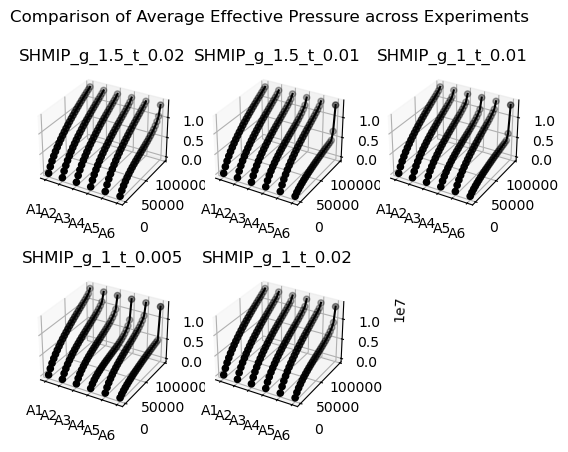

In [8]:
make_compare_effecpress_plots(folders,'Comparison of Average Effective Pressure across Experiments')